<a href="https://colab.research.google.com/github/saim9211/DeepLearning/blob/main/02_pytorch_neuralnet_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resources need to cover
link: https://www.learnpytorch.io/02_pytorch_classification/

Topic	Contents
0. Architecture of a classification neural network	Neural networks can come in almost any shape or size, but they typically follow a similar floor plan.
1. Getting binary classification data ready	Data can be almost anything but to get started we're going to create a simple binary classification dataset.
2. Building a PyTorch classification model	Here we'll create a model to learn patterns in the data, we'll also choose a loss function, optimizer and build a training loop specific to classification.
3. Fitting the model to data (training)	We've got data and a model, now let's let the model (try to) find patterns in the (training) data.
4. Making predictions and evaluating a model (inference)	Our model's found patterns in the data, let's compare its findings to the actual (testing) data.
5. Improving a model (from a model perspective)	We've trained and evaluated a model but it's not working, let's try a few things to improve it.
6. Non-linearity	So far our model has only had the ability to model straight lines, what about non-linear (non-straight) lines?
7. Replicating non-linear functions	We used non-linear functions to help model non-linear data, but what do these look like?
8. Putting it all together with multi-class classification	Let's put everything we've done so far for binary classification together with a multi-class classification problem.

In [91]:
# make the classsification data and get ready
import sklearn

from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [92]:
len(X),len(y)

(1000, 1000)

 So
 it is the binary classification data

In [93]:
print(f"first five sample of x: {X[:5]}")
print(f"first five sample of y: {y[:5]}")

first five sample of x: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
first five sample of y: [1 1 1 1 0]


In [94]:
# make the data frames of circle data
import pandas as  pd
circle=pd.DataFrame({"x1":X[:,0],
                  "x2":X[:,1],
                  "label":y})
circle.head()

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [95]:
len(circle['x2'])

1000

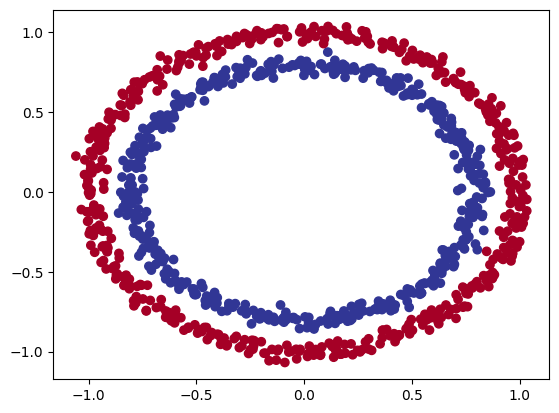

In [96]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

#### note: data we were working is oftern refered to as toy dataset  , a dataset that is small enough to experiement but ok for the practice

1.1 check the input and out shape


In [97]:
# bcz the shape is the main issue commonly
X.shape,y.shape

((1000, 2), (1000,))

In [98]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [99]:
# view the first example of the features and labels
X_sample=X[0]
y_sample=y[0]
print(f"sample of x: {X_sample} and the shape {X_sample.shape}")
print(f"sample of y: {y_sample} and the shape {y_sample.shape}")


sample of x: [0.75424625 0.23148074] and the shape (2,)
sample of y: 1 and the shape ()


### 1.2 turn the data in to tensors and train/test splits

In [100]:
# turn the data un to tensor
import torch
torch.__version__

'2.11.0+cpu'

In [101]:
type(X),X.dtype

(numpy.ndarray, dtype('float64'))

In [102]:
# turn data in to tensor

# so we have the data in to numpy array so we convert them in to tensor
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [103]:
type(X),X.dtype

(torch.Tensor, torch.float32)

In [104]:
#splitting the data in to training and test splits
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [105]:
len(X_train),len(y_train),len(X_test),len(y_test)

(800, 800, 200, 200)

### 2. Building model
lets build a model to classify our red,blue dots

to do so , we want to
1. set up device agnostic code
2. construct a model by subclassing 'nn.Module'
3. Define the loss and optimizer
4. Training and Testing loop

In [106]:
# import  the pytorch
import torch
from torch import nn

# make the agnostic code
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [107]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we have to set up agnostic code, create the model
1. subclass 'nn.Module'
2. create linear layers 'nn.Linear()'
3. define forward methods
4. loss function
5

In [108]:
# construct  amodel by class
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        # create the linear layers
        self.layer1=nn.Linear(in_features=2,out_features=5) # take in 2 inp feature and out feature 5
        self.layer2=nn.Linear(in_features=5,out_features=5)# take the 5 inp feaure from prev layer and output feature 5
        self.layer3=nn.Linear(in_features=5,out_features=1)# take the 5 out feature of prev layer as inp for its self and out 1 feature
    #define the forwad method
    def forward(self,x):
        return self.layer3(self.layer2(self.layer1(x)))
# instantiate an instance of our model and send to device
model_0=CircleModel().to(device)
model_0

CircleModel(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=5, bias=True)
  (layer3): Linear(in_features=5, out_features=1, bias=True)
)

###making the model simple way is the nn.sequential but for the complex model we apply the rule of same sub layers

In [109]:
# replacing the above code with the nn.squentials
model_0=nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=5, bias=True)
  (2): Linear(in_features=5, out_features=1, bias=True)
)

In [110]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2732, -0.5424],
                      [ 0.5802,  0.2037],
                      [ 0.2929,  0.2236],
                      [-0.0123,  0.5534],
                      [-0.5024,  0.0445]])),
             ('0.bias', tensor([-0.4826,  0.2180, -0.2435,  0.2167, -0.1473])),
             ('1.weight',
              tensor([[ 0.3709, -0.2651, -0.2667, -0.2667,  0.4022],
                      [ 0.1490,  0.4303, -0.3691, -0.4436, -0.3499],
                      [-0.3008,  0.1811,  0.1601,  0.3716, -0.2310],
                      [-0.3049,  0.2373, -0.1808,  0.2714, -0.1061],
                      [ 0.2558, -0.3475, -0.2257,  0.1363,  0.0945]])),
             ('1.bias', tensor([-0.1140,  0.2666,  0.3040, -0.3243, -0.2388])),
             ('2.weight',
              tensor([[ 0.4095, -0.1509, -0.1585, -0.4327, -0.2561]])),
             ('2.bias', tensor([0.1117]))])

In [111]:
#make prediction
with torch.inference_mode():
  untrained_pred=model_0(X_test.to(device))
print(f"length of prediction: {len(untrained_pred)}")
print(f"shape of prediction: {untrained_pred.shape}")
print(f"print first 10 prediction: {untrained_pred[:10]}")
print(f"print first 10 actual labels: {y_test[:10]}")


length of prediction: 200
shape of prediction: torch.Size([200, 1])
print first 10 prediction: tensor([[-0.1784],
        [-0.3804],
        [ 0.2139],
        [-0.2889],
        [-0.0043],
        [-0.1260],
        [-0.5220],
        [-0.4630],
        [ 0.2225],
        [-0.3964]])
print first 10 actual labels: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [112]:
# loss function
# in previous for regression we used the llloss but for the classification we used the cross val BCE WITH LOGISTIC LOSS()
# loss_fn=nn.BCELoss() # bce=required input to have gone through the sigmoid function  prior to inp to bceloss
loss_fn=nn.BCEWithLogitsLoss() # bcewithlogitloss  = sigmoid activation function builtin  and more stable than using the plain sigmoid function
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


In [113]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2732, -0.5424],
                      [ 0.5802,  0.2037],
                      [ 0.2929,  0.2236],
                      [-0.0123,  0.5534],
                      [-0.5024,  0.0445]])),
             ('0.bias', tensor([-0.4826,  0.2180, -0.2435,  0.2167, -0.1473])),
             ('1.weight',
              tensor([[ 0.3709, -0.2651, -0.2667, -0.2667,  0.4022],
                      [ 0.1490,  0.4303, -0.3691, -0.4436, -0.3499],
                      [-0.3008,  0.1811,  0.1601,  0.3716, -0.2310],
                      [-0.3049,  0.2373, -0.1808,  0.2714, -0.1061],
                      [ 0.2558, -0.3475, -0.2257,  0.1363,  0.0945]])),
             ('1.bias', tensor([-0.1140,  0.2666,  0.3040, -0.3243, -0.2388])),
             ('2.weight',
              tensor([[ 0.4095, -0.1509, -0.1585, -0.4327, -0.2561]])),
             ('2.bias', tensor([0.1117]))])

In [114]:
# calculate the accuracy  - out of 100 examp what perc does our model get right ?
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=correct/len(y_pred)
  return acc

### train model

steps to follow:
1. forward pass
2. cal loss
3. optimize to zero_grad
4. back propagation
5. optimize step

### 3.1 going from raw logits -> prediction_probabilities-> prediction labels



In [115]:
model_0.eval()
with torch.inference_mode():
  y_logits=model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1784],
        [-0.3804],
        [ 0.2139],
        [-0.2889],
        [-0.0043]])

In [116]:
# use the sigmoid function on logits bcz its activation function
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4555],
        [0.4060],
        [0.5533],
        [0.4283],
        [0.4989]])

### what the rounding do :
1. y_pred_prob >=5 y=1 class 1
2. y_pred_prob <5 y=0 class 0

In [117]:
# now get the values in same formate like the target ones y_test
y_preds=torch.round(y_pred_probs)
# in full ( logits -> pred_prob -> pred_lables)
y_pred_labels=torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check the equality
print(torch.eq(y_preds.to(device),y_pred_labels))
# get the rid of extra dimension
y_preds.squeeze()



tensor([[True],
        [True],
        [True],
        [True],
        [True]])


tensor([0., 0., 1., 0., 0.])

#### creating the training and testing loop

In [118]:
torch.manual_seed(42)

#set the size of the epoch
epochs=200

# put the data to target device
X_train,X_test=X_train.to(device),X_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)

# built the train and testinng loop
for epoch in range(epochs):
  # model train
  model_0(X_train)

  # forward pass
  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  # loss function/acc
  loss=loss_fn(y_logits,y_train)
  accuracy=accuracy_fn(y_true=y_train,y_pred=y_pred)

  # optimzer zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimzer step
  optimizer.step()

  # testing loop

  # evaluation
  model_0.eval()

  #making prediction on testing data
  with torch.inference_mode():
    # forwad pass
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    # loss and accuracy
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_true=y_test,y_pred=test_pred)

  # print out  what happening
  if epoch % 10 == 0:
    print(f"epoch: {epoch} | loss: {loss:.5f}% | accuracy: {accuracy:.2f}%| test_loss: {test_loss:.5f}%")
#


epoch: 0 | loss: 0.70550% | accuracy: 0.48%| test_loss: 0.69466%
epoch: 10 | loss: 0.70078% | accuracy: 0.48%| test_loss: 0.69194%
epoch: 20 | loss: 0.69865% | accuracy: 0.49%| test_loss: 0.69120%
epoch: 30 | loss: 0.69738% | accuracy: 0.49%| test_loss: 0.69100%
epoch: 40 | loss: 0.69649% | accuracy: 0.50%| test_loss: 0.69099%
epoch: 50 | loss: 0.69581% | accuracy: 0.50%| test_loss: 0.69106%
epoch: 60 | loss: 0.69529% | accuracy: 0.50%| test_loss: 0.69117%
epoch: 70 | loss: 0.69487% | accuracy: 0.50%| test_loss: 0.69131%
epoch: 80 | loss: 0.69454% | accuracy: 0.50%| test_loss: 0.69147%
epoch: 90 | loss: 0.69426% | accuracy: 0.50%| test_loss: 0.69164%
epoch: 100 | loss: 0.69404% | accuracy: 0.50%| test_loss: 0.69181%
epoch: 110 | loss: 0.69386% | accuracy: 0.51%| test_loss: 0.69199%
epoch: 120 | loss: 0.69371% | accuracy: 0.51%| test_loss: 0.69216%
epoch: 130 | loss: 0.69358% | accuracy: 0.51%| test_loss: 0.69233%
epoch: 140 | loss: 0.69348% | accuracy: 0.51%| test_loss: 0.69249%
epoch:

### Make prediction and evalute the model

from the metrics it look like our model is  not learning any thing
so inspect it let make some perdiction and make them visual


In [119]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


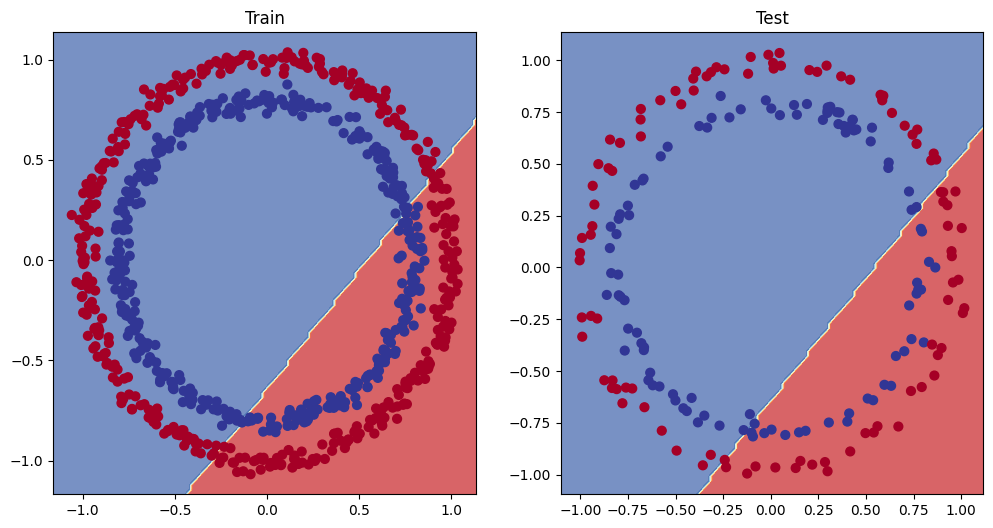

In [120]:
# we discuss the decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


### improving the model (from model perspective)
1. add more layers
2. add more hidden unicode_std_stream
3. changing the activation function
4. change the optimization func
5. change the lr  

 And these options are all from model perspective so deal with model directly


 Let try and imporve our model by:


1.   Adding more hidden unit
2.   increase the number of layers
3. increase the number of epochs



In [149]:
class CircleModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Linear(in_features=2,out_features=10)
    self.layer2=nn.Linear(in_features=10,out_features=10)
    self.layer3=nn.Linear(in_features=10,out_features=1)
    self.relu = nn.ReLU() # Define ReLU once here

  def forward(self,x):
    # Apply ReLU after each hidden layer
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))
model_1=CircleModelv2().to(device)
model_1

CircleModelv2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [161]:
loss_fn_instance=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)

In [164]:
torch.manual_seed(42)

#set the size of the epoch
epochs=200

# put the data to target device
X_train,X_test=X_train.to(device),X_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)

for epoch in range(epochs):
  # model train
  model_1.train()
  logit=model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(logit))

  # Calculate loss and accuracy using the defined instances/functions
  train_loss = loss_fn_instance(logit,y_train) # Use the global 'loss_fn_instance'
  train_accuracy = accruacy(y_true=y_train,y_pred=y_pred) # Use the global 'accruacy' (accuracy_fn)

  optimizer.zero_grad()
  train_loss.backward()
  optimizer.step()

  # testing loop

  model_1.eval()
  with torch.inference_mode():
    test_logit=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logit))

    test_loss_val = loss_fn_instance(test_logit,y_test) # Use the global 'loss_fn_instance'
    test_acc_val = accruacy(y_true=y_test,y_pred=test_pred) # Use the global 'accruacy'
  if epoch % 10 == 0:
    print(f"epoch: {epoch} | loss: {train_loss:.5f}% | accuracy: {train_accuracy:.2f}%| test_loss: {test_loss_val:.5f}% | test_accuracy: {test_acc_val:.2f}%")

epoch: 0 | loss: 0.57396% | accuracy: 0.87%| test_loss: 0.58280% | test_accuracy: 0.83%
epoch: 10 | loss: 0.56626% | accuracy: 0.88%| test_loss: 0.57588% | test_accuracy: 0.88%
epoch: 20 | loss: 0.55829% | accuracy: 0.90%| test_loss: 0.56847% | test_accuracy: 0.90%
epoch: 30 | loss: 0.54990% | accuracy: 0.91%| test_loss: 0.56045% | test_accuracy: 0.90%
epoch: 40 | loss: 0.54119% | accuracy: 0.92%| test_loss: 0.55217% | test_accuracy: 0.91%
epoch: 50 | loss: 0.53232% | accuracy: 0.93%| test_loss: 0.54403% | test_accuracy: 0.91%
epoch: 60 | loss: 0.52350% | accuracy: 0.94%| test_loss: 0.53599% | test_accuracy: 0.91%
epoch: 70 | loss: 0.51458% | accuracy: 0.95%| test_loss: 0.52761% | test_accuracy: 0.92%
epoch: 80 | loss: 0.50560% | accuracy: 0.95%| test_loss: 0.51943% | test_accuracy: 0.94%
epoch: 90 | loss: 0.49647% | accuracy: 0.95%| test_loss: 0.51135% | test_accuracy: 0.94%
epoch: 100 | loss: 0.48730% | accuracy: 0.96%| test_loss: 0.50307% | test_accuracy: 0.94%
epoch: 110 | loss: 0.

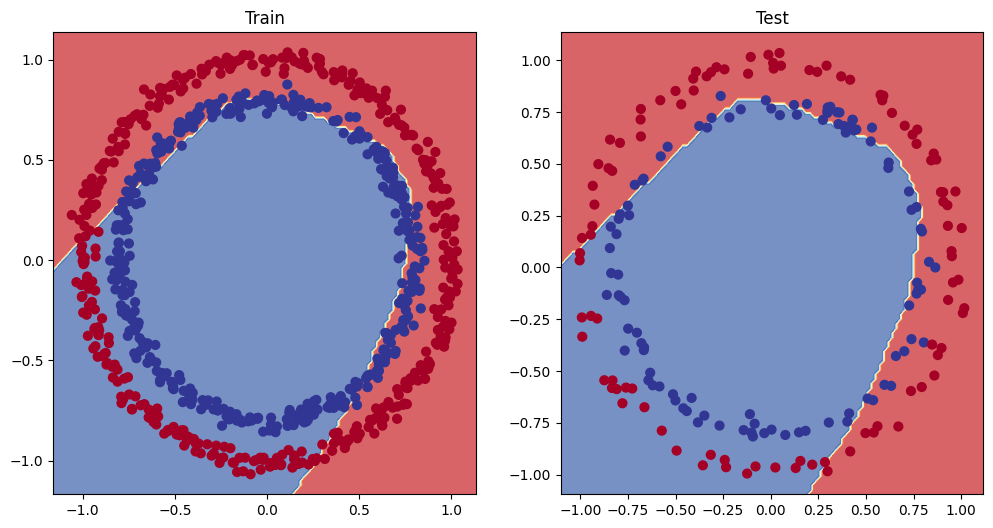

In [152]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### preparing data to see if our model can fit to straights line
one way to trouble shoot the large problem is to test out a small problem

In [153]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [154]:
# Create train and test splits
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each split
print(len(X_train_regression),
    len(y_train_regression),
    len(X_test_regression),
    len(y_test_regression))

80 80 20 20


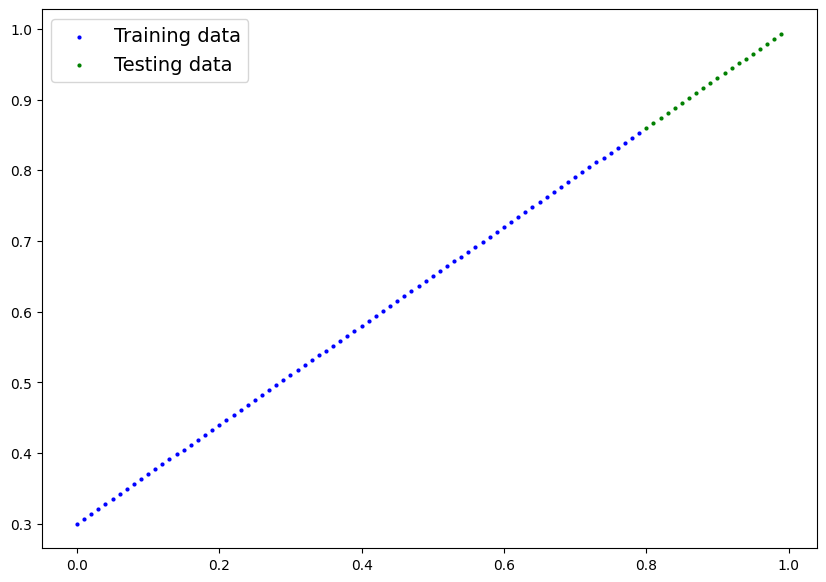

In [155]:
plot_predictions(train_data=X_train_regression,
    train_labels=y_train_regression,
    test_data=X_test_regression,
    test_labels=y_test_regression
);

In [156]:
# Same architecture as model_1 (but using nn.Sequential)
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [157]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)

In [165]:
# Train the model
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
    ### Training
    # 1. Forward pass
    y_pred = model_2(X_train_regression)

    # 2. Calculate loss (no accuracy since it's a regression problem, not classification)
    loss = loss_fn(y_pred, y_train_regression)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_2.eval()
    with torch.inference_mode():
      # 1. Forward pass
      test_pred = model_2(X_test_regression)
      # 2. Calculate the loss
      test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch: 0 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 10 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 20 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 30 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 40 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 50 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 60 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 70 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 80 | Train loss: 0.04710, Test loss: 0.08914
Epoch: 90 | Train loss: 0.04710, Test loss: 0.08914


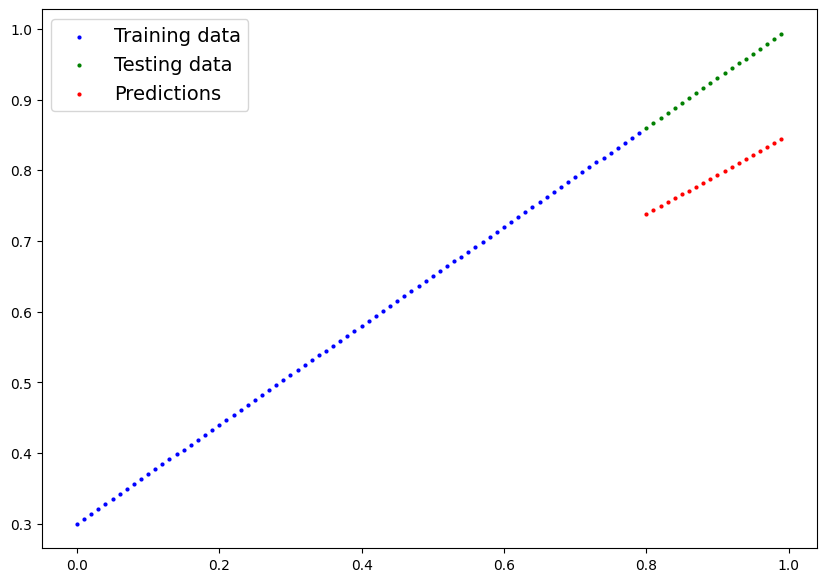

In [159]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());